# 🧠 Neural Networks — Complete ML Interview Preparation

> **Covers:** Perceptron → MLP · Backpropagation (full derivation) · Activation Functions · Vanishing/Exploding Gradients · Optimizers (SGD, Adam) · Batch Normalization · Training Pipelines · Optimization Techniques · Transfer Learning · Overfitting & Regularization · CNNs · RNNs · LSTMs

**How to use this notebook:** Run each cell top-to-bottom. Every section has:
- 📝 **Theory** in markdown with full math
- 💻 **Working code** you can run and experiment with
- 🎯 **Interview tips** highlighted throughout

---

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 5)
matplotlib.rcParams['font.size'] = 12
np.random.seed(42)
print("✅ Setup complete")

✅ Setup complete


---
# 1. From Perceptron to Multi-Layer Perceptron (MLP)

## 1.1 The Perceptron

The simplest neural network — a single artificial neuron.

$$y = \sigma\left(\sum_{i=1}^{n} w_i x_i + b\right) = \sigma(\mathbf{w}^T\mathbf{x} + b)$$

| Component | Role |
|-----------|------|
| $\mathbf{x}$ | Input features |
| $\mathbf{w}$ | Learnable weights |
| $b$ | Bias term |
| $\sigma$ | Activation function |

**Key Limitation:** Can only learn **linearly separable** functions.

### The XOR Problem

XOR cannot be solved by a single perceptron — no single line can separate `(0,0),(1,1)` from `(0,1),(1,0)`.

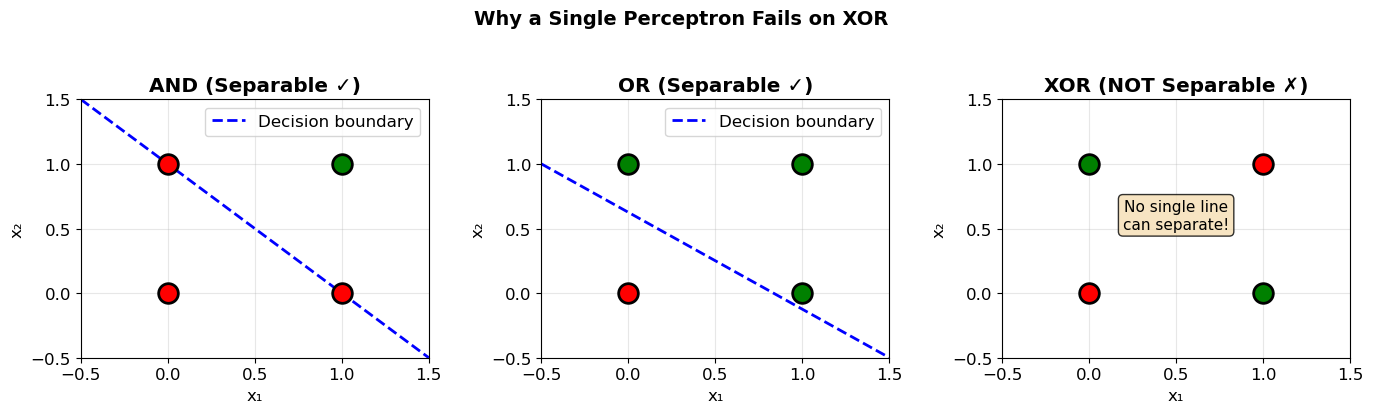

In [2]:
# Visualize the XOR problem
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

X = np.array([[0,0],[0,1],[1,0],[1,1]])
problems = [
    ('AND (Separable ✓)', [0,0,0,1], True),
    ('OR (Separable ✓)',  [0,1,1,1], True),
    ('XOR (NOT Separable ✗)', [0,1,1,0], False),
]

for ax, (title, y, separable) in zip(axes, problems):
    for xi, yi in zip(X, y):
        ax.scatter(xi[0], xi[1], c='green' if yi else 'red', s=200, zorder=5, edgecolors='black', linewidth=2)
    if separable:
        if 'AND' in title:
            ax.plot([-0.5, 1.5], [1.5, -0.5], 'b--', linewidth=2, label='Decision boundary')
        else:
            ax.plot([-0.5, 1.5], [1.0, -0.5], 'b--', linewidth=2, label='Decision boundary')
        ax.legend()
    else:
        ax.annotate('No single line\ncan separate!', xy=(0.5, 0.5), fontsize=11, ha='center',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

plt.suptitle('Why a Single Perceptron Fails on XOR', fontweight='bold', y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

## 1.2 Perceptron Learning Algorithm (from scratch)

In [3]:
class Perceptron:
    """Single-layer perceptron with step activation."""
    def __init__(self, n_features, lr=0.1):
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.lr = lr

    def predict(self, X):
        return (X @ self.weights + self.bias >= 0.5).astype(int)

    def fit(self, X, y, epochs=100):
        errors_per_epoch = []
        for epoch in range(epochs):
            errors = 0
            for xi, yi in zip(X, y):
                pred = int(xi @ self.weights + self.bias >= 0.5)
                error = yi - pred
                self.weights += self.lr * error * xi
                self.bias += self.lr * error
                errors += int(error != 0)
            errors_per_epoch.append(errors)
            if errors == 0:
                print(f"  Converged at epoch {epoch+1}")
                break
        return errors_per_epoch

X = np.array([[0,0],[0,1],[1,0],[1,1]])

print("=== Perceptron on AND ===")
p_and = Perceptron(2)
p_and.fit(X, np.array([0,0,0,1]))
print(f"  Predictions: {p_and.predict(X)}")
print(f"  Expected:    [0 0 0 1]\n")

print("=== Perceptron on XOR ===")
p_xor = Perceptron(2)
history = p_xor.fit(X, np.array([0,1,1,0]), epochs=200)
print(f"  Predictions: {p_xor.predict(X)}")
print(f"  Expected:    [0 1 1 0]")
print(f"  ❌ Never converges — errors in last epoch: {history[-1]}")

=== Perceptron on AND ===
  Converged at epoch 3
  Predictions: [0 0 0 1]
  Expected:    [0 0 0 1]

=== Perceptron on XOR ===
  Predictions: [1 1 0 0]
  Expected:    [0 1 1 0]
  ❌ Never converges — errors in last epoch: 4


## 


1.3 Multi-Layer Perceptron (MLP)

By stacking layers with **non-linear activations**, we break the linearity constraint.

$$\mathbf{h}_1 = \sigma(W_1 \mathbf{x} + \mathbf{b}_1)$$
$$\mathbf{h}_2 = \sigma(W_2 \mathbf{h}_1 + \mathbf{b}_2)$$
$$\hat{y} = \text{softmax}(W_3 \mathbf{h}_2 + \mathbf{b}_3)$$

> **Universal Approximation Theorem:** An MLP with at least one hidden layer and a non-linear activation can approximate *any* continuous function on a compact subset of $\mathbb{R}^n$.

MLP XOR Results:
  Input: [0 0]  Expected: 0  Predicted: 0.0260  Rounded: 0
  Input: [0 1]  Expected: 1  Predicted: 0.4988  Rounded: 0
  Input: [1 0]  Expected: 1  Predicted: 0.9752  Rounded: 1
  Input: [1 1]  Expected: 0  Predicted: 0.5011  Rounded: 1


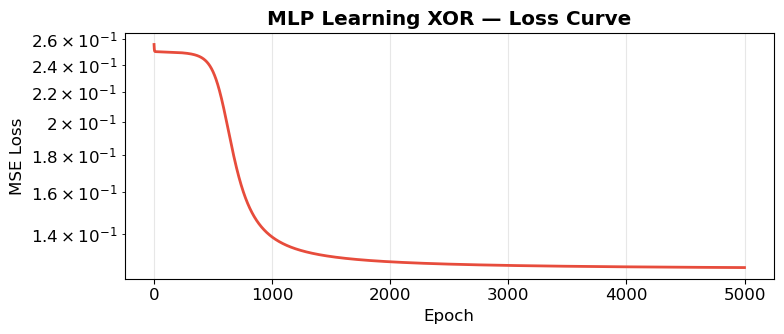

In [4]:
class MLP_XOR:
    """Minimal MLP to solve XOR: 2 -> 2 hidden -> 1 output."""
    def __init__(self, lr=0.5):
        self.W1 = np.random.randn(2, 2) * np.sqrt(2.0/2)
        self.b1 = np.zeros(2)
        self.W2 = np.random.randn(2, 1) * np.sqrt(2.0/2)
        self.b2 = np.zeros(1)
        self.lr = lr

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        m = X.shape[0]
        sig_d = lambda a: a * (1 - a)
        dz2 = (self.a2 - y.reshape(-1,1)) * sig_d(self.a2)
        dW2 = self.a1.T @ dz2 / m
        db2 = dz2.mean(axis=0)
        dz1 = (dz2 @ self.W2.T) * sig_d(self.a1)
        dW1 = X.T @ dz1 / m
        db1 = dz1.mean(axis=0)
        self.W2 -= self.lr * dW2;  self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1;  self.b1 -= self.lr * db1

    def train(self, X, y, epochs=10000):
        losses = []
        for _ in range(epochs):
            pred = self.forward(X)
            losses.append(np.mean((pred.flatten() - y)**2))
            self.backward(X, y)
        return losses

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0, 1, 1, 0])

np.random.seed(42)
mlp = MLP_XOR(lr=2.0)
losses = mlp.train(X, y, epochs=5000)

preds = mlp.forward(X).flatten()
print("MLP XOR Results:")
for xi, yi, pi in zip(X, y, preds):
    print(f"  Input: {xi}  Expected: {yi}  Predicted: {pi:.4f}  Rounded: {round(pi)}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(losses, linewidth=2, color='#e74c3c')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('MLP Learning XOR — Loss Curve', fontweight='bold')
ax.set_yscale('log'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
# 2. Backpropagation — Full Derivation

Backpropagation computes $\frac{\partial \mathcal{L}}{\partial w}$ for every weight using the **chain rule**.

## 2.1 Step-by-Step Derivation

Consider: $x \xrightarrow{W_1} z_1 \xrightarrow{\sigma} a_1 \xrightarrow{W_2} z_2 \xrightarrow{\sigma} a_2 \xrightarrow{\mathcal{L}} \text{loss}$

### Forward Pass:
$$z_1 = W_1 x + b_1, \quad a_1 = \sigma(z_1)$$
$$z_2 = W_2 a_1 + b_2, \quad a_2 = \sigma(z_2)$$
$$\mathcal{L} = \frac{1}{2}(a_2 - y)^2$$

### Backward Pass:

| Step | Gradient | Formula |
|------|----------|---------|
| 1. Loss → output | $\frac{\partial \mathcal{L}}{\partial a_2}$ | $a_2 - y$ |
| 2. Through activation | $\frac{\partial \mathcal{L}}{\partial z_2}$ | $\frac{\partial \mathcal{L}}{\partial a_2} \cdot \sigma'(z_2)$ |
| 3. Weight gradient | $\frac{\partial \mathcal{L}}{\partial W_2}$ | $\frac{\partial \mathcal{L}}{\partial z_2} \cdot a_1^T$ |
| 4. Propagate back | $\frac{\partial \mathcal{L}}{\partial a_1}$ | $W_2^T \cdot \frac{\partial \mathcal{L}}{\partial z_2}$ |
| 5. Through activation | $\frac{\partial \mathcal{L}}{\partial z_1}$ | $\frac{\partial \mathcal{L}}{\partial a_1} \cdot \sigma'(z_1)$ |
| 6. Weight gradient | $\frac{\partial \mathcal{L}}{\partial W_1}$ | $\frac{\partial \mathcal{L}}{\partial z_1} \cdot x^T$ |

> 🎯 **Interview insight:** We cache forward-pass values ($z$, $a$) to reuse during backprop. This is why training uses ~2× the memory of inference.

### Cross-entropy + Softmax shortcut:
$$\frac{\partial \mathcal{L}}{\partial z} = \text{softmax}(z) - y$$
The $\sigma'(z)$ term cancels out — no vanishing gradient at the output layer!

In [5]:
# Gradient checking — verify our backprop is correct
def numerical_gradient(f, params, eps=1e-5):
    """Compute numerical gradient for verification."""
    grads = []
    for p in params:
        grad = np.zeros_like(p)
        it = np.nditer(p, flags=['multi_index'])
        while not it.finished:
            idx = it.multi_index
            old_val = p[idx]
            p[idx] = old_val + eps
            loss_plus = f()
            p[idx] = old_val - eps
            loss_minus = f()
            grad[idx] = (loss_plus - loss_minus) / (2 * eps)
            p[idx] = old_val
            it.iternext()
        grads.append(grad)
    return grads

np.random.seed(0)
x = np.array([[1.0, 2.0]])
y_true = np.array([[1.0]])
W1 = np.random.randn(2, 3) * 0.5
b1 = np.zeros((1, 3))
W2 = np.random.randn(3, 1) * 0.5
b2 = np.zeros((1, 1))

sigmoid = lambda z: 1 / (1 + np.exp(-z))

def forward_loss():
    z1 = x @ W1 + b1; a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2; a2 = sigmoid(z2)
    return 0.5 * np.sum((a2 - y_true)**2)

# Analytic gradients (backprop)
z1 = x @ W1 + b1; a1 = sigmoid(z1)
z2 = a1 @ W2 + b2; a2 = sigmoid(z2)

dz2 = (a2 - y_true) * a2 * (1 - a2)
dW2_an = a1.T @ dz2
da1 = dz2 @ W2.T
dz1 = da1 * a1 * (1 - a1)
dW1_an = x.T @ dz1

# Numerical gradients
num_grads = numerical_gradient(forward_loss, [W1, b1, W2, b2])

print("Gradient Checking (differences should be < 1e-7):")
print(f"  dW1: {np.max(np.abs(dW1_an - num_grads[0])):.2e}")
print(f"  dW2: {np.max(np.abs(dW2_an - num_grads[2])):.2e}")
print("\n✅ Backprop verified — analytic gradients match numerical!")

Gradient Checking (differences should be < 1e-7):
  dW1: 2.35e-12
  dW2: 7.39e-13

✅ Backprop verified — analytic gradients match numerical!


---
# 3. Activation Functions

**Why non-linearity is essential:** Without it, stacking layers is useless —  
$W_2(W_1 x + b_1) + b_2 = W'x + b'$ (collapses to one linear layer).

## Comparison Table

| Function | Formula | Range | Key Property |
|----------|---------|-------|-------------|
| **Sigmoid** | $\frac{1}{1+e^{-x}}$ | $(0,1)$ | Prob. output; vanishing gradient ($\sigma' \leq 0.25$) |
| **Tanh** | $\frac{e^x - e^{-x}}{e^x + e^{-x}}$ | $(-1,1)$ | Zero-centered; still vanishes |
| **ReLU** | $\max(0,x)$ | $[0,\infty)$ | No vanishing (x>0); dying ReLU problem |
| **Leaky ReLU** | $\max(\alpha x, x)$ | $(-\infty,\infty)$ | Fixes dying ReLU ($\alpha \approx 0.01$) |
| **ELU** | $x$ if $x>0$; $\alpha(e^x-1)$ else | $(-\alpha,\infty)$ | Smooth, zero-centered |
| **GELU** | $x \cdot \Phi(x)$ | ≈$(-0.17,\infty)$ | Used in BERT, GPT |
| **Swish/SiLU** | $x \cdot \sigma(x)$ | ≈$(-0.28,\infty)$ | Used in EfficientNet |

> 🎯 **Interview tip:** Default to **ReLU** for hidden layers. Use **sigmoid** for binary output, **softmax** for multi-class output. Modern transformers use **GELU**.

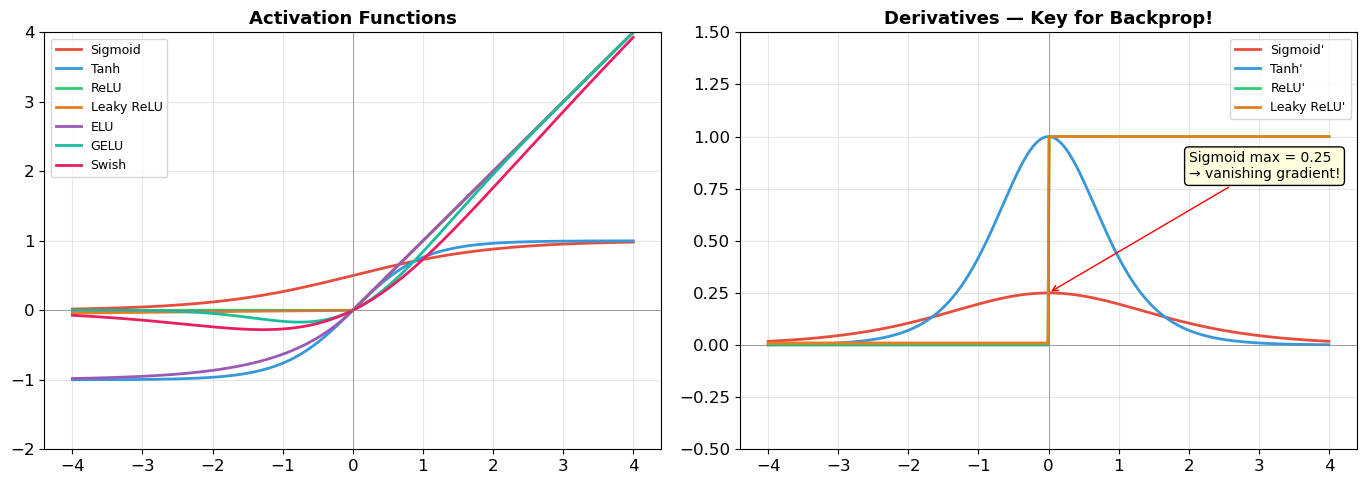

In [6]:
# Visualize all activation functions and their derivatives
x = np.linspace(-4, 4, 500)

sigmoid = lambda x: 1 / (1 + np.exp(-x))
activations = [
    ('Sigmoid',    sigmoid,                               lambda x: sigmoid(x)*(1-sigmoid(x)),   '#e74c3c'),
    ('Tanh',       np.tanh,                                lambda x: 1-np.tanh(x)**2,            '#3498db'),
    ('ReLU',       lambda x: np.maximum(0,x),              lambda x: (x>0).astype(float),         '#2ecc71'),
    ('Leaky ReLU', lambda x: np.where(x>0, x, 0.01*x),    lambda x: np.where(x>0, 1, 0.01),     '#e67e22'),
    ('ELU',        lambda x: np.where(x>0, x, np.exp(x)-1),None,                                  '#9b59b6'),
    ('GELU',       lambda x: x*0.5*(1+np.tanh(np.sqrt(2/np.pi)*(x+0.044715*x**3))), None,        '#1abc9c'),
    ('Swish',      lambda x: x*sigmoid(x),                 None,                                  '#e91e63'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, func, deriv, color in activations:
    axes[0].plot(x, func(x), label=name, linewidth=2, color=color)
axes[0].axhline(0, color='gray', lw=0.5); axes[0].axvline(0, color='gray', lw=0.5)
axes[0].set_title('Activation Functions', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3); axes[0].set_ylim(-2, 4)

for name, _, deriv, color in activations:
    if deriv is not None:
        axes[1].plot(x, deriv(x), label=f"{name}'", linewidth=2, color=color)
axes[1].axhline(0, color='gray', lw=0.5); axes[1].axvline(0, color='gray', lw=0.5)
axes[1].set_title("Derivatives — Key for Backprop!", fontweight='bold', fontsize=13)
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3); axes[1].set_ylim(-0.5, 1.5)
axes[1].annotate('Sigmoid max = 0.25\n→ vanishing gradient!', xy=(0, 0.25), xytext=(2, 0.8),
                fontsize=10, arrowprops=dict(arrowstyle='->', color='red'),
                bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.tight_layout(); plt.show()

---
# 4. Vanishing & Exploding Gradients

## The Core Problem

For an $L$-layer network, the gradient at layer 1 involves a chain of multiplications:

$$\frac{\partial \mathcal{L}}{\partial W_1} = \frac{\partial \mathcal{L}}{\partial a_L} \cdot \prod_{i=2}^{L} \left( W_i \cdot \sigma'(z_i) \right)$$

| Condition | Result | Problem |
|-----------|--------|---------|
| $\|W_i \cdot \sigma'(z_i)\| < 1$ | Product → $0$ | **Vanishing** — early layers don't learn |
| $\|W_i \cdot \sigma'(z_i)\| > 1$ | Product → $\infty$ | **Exploding** — NaN losses |

Sigmoid guarantees shrinkage: $\sigma'(x) \leq 0.25$, so each layer shrinks gradients by ≥75%.

## Solutions

| Problem | Solution | Mechanism |
|---------|----------|-----------|
| Vanishing | **ReLU** | $\sigma'(x) = 1$ for $x > 0$ |
| Vanishing | **Skip connections** (ResNet) | $y = F(x) + x$ — gradient flows through the $+x$ |
| Vanishing | **BatchNorm** | Stabilizes activation distributions |
| Vanishing | **LSTM/GRU gates** | Cell state as gradient highway |
| Exploding | **Gradient clipping** | $g = \text{threshold} \cdot g / \|g\|$ if $\|g\| > \text{threshold}$ |
| Both | **Proper initialization** | Keep $\text{Var}(\text{activations}) \approx 1$ |

## Weight Initialization

- **Xavier/Glorot** (sigmoid/tanh): $\text{Var}(w) = \frac{2}{n_{in} + n_{out}}$
- **He/Kaiming** (ReLU): $\text{Var}(w) = \frac{2}{n_{in}}$

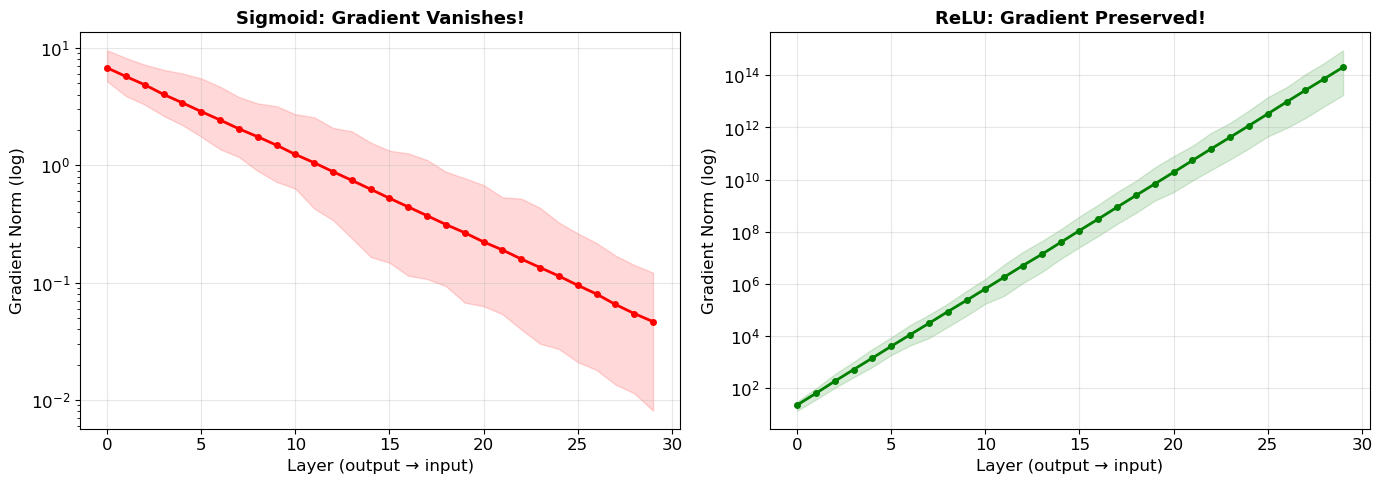

Sigmoid drops gradient by ~10¹⁵ over 30 layers — early layers are frozen.


In [7]:
# Demonstrate vanishing gradients: sigmoid vs ReLU
np.random.seed(42)
sigmoid = lambda x: 1 / (1 + np.exp(-x))

def simulate_gradient_flow(n_layers, activation='sigmoid', n_sims=100):
    gradient_norms = np.zeros((n_sims, n_layers))
    for sim in range(n_sims):
        grad = np.random.randn(64)
        for layer in range(n_layers):
            W = np.random.randn(64, 64) * 0.5
            if activation == 'sigmoid':
                z = np.random.randn(64)
                grad = (W.T @ grad) * (sigmoid(z) * (1 - sigmoid(z)))
            else:  # relu
                grad = (W.T @ grad) * (np.random.randn(64) > 0).astype(float)
            gradient_norms[sim, layer] = np.linalg.norm(grad)
    return gradient_norms

n_layers = 30
sig_grads = simulate_gradient_flow(n_layers, 'sigmoid')
relu_grads = simulate_gradient_flow(n_layers, 'relu')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, name, color in [(axes[0], sig_grads, 'Sigmoid: Gradient Vanishes!', 'red'),
                               (axes[1], relu_grads, 'ReLU: Gradient Preserved!', 'green')]:
    mean = data.mean(axis=0)
    ax.semilogy(range(n_layers), mean, f'-o', color=color, markersize=4, linewidth=2)
    ax.fill_between(range(n_layers), data.min(axis=0), data.max(axis=0), alpha=0.15, color=color)
    ax.set_title(name, fontweight='bold', fontsize=13)
    ax.set_xlabel('Layer (output → input)'); ax.set_ylabel('Gradient Norm (log)')
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print("Sigmoid drops gradient by ~10¹⁵ over 30 layers — early layers are frozen.")

### Weight Initialization — Visualized

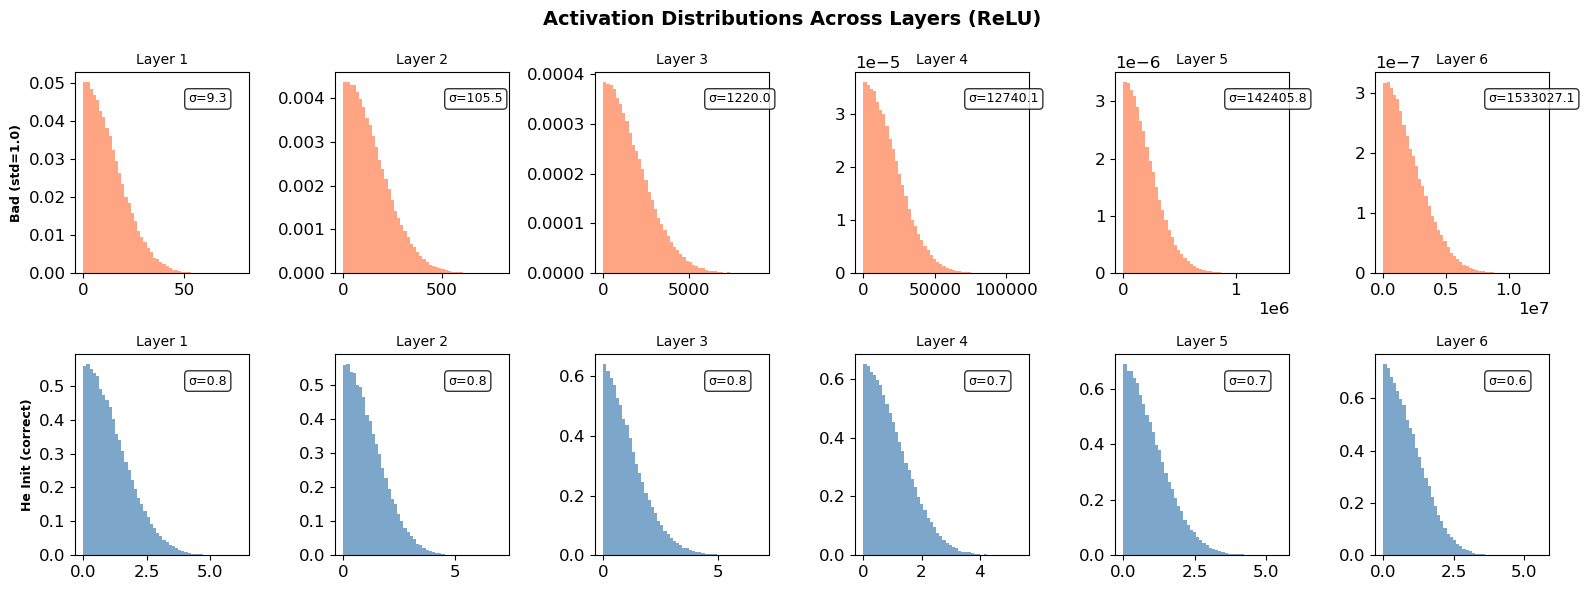

In [8]:
# Effect of initialization on activation distributions
np.random.seed(42)
n_layers, layer_size = 6, 256
x = np.random.randn(1000, layer_size)

fig, axes = plt.subplots(2, n_layers, figsize=(16, 6))

inits = {
    'Bad (std=1.0)': lambda n_in, n_out: np.random.randn(n_in, n_out) * 1.0,
    'He Init (correct)': lambda n_in, n_out: np.random.randn(n_in, n_out) * np.sqrt(2.0/n_in),
}

for row, (name, init_fn) in enumerate(inits.items()):
    h = x.copy()
    for i in range(n_layers):
        W = init_fn(layer_size, layer_size)
        h = np.maximum(0, h @ W)  # ReLU
        axes[row, i].hist(h.flatten()[h.flatten() != 0], bins=50, density=True, alpha=0.7,
                         color='coral' if row == 0 else 'steelblue')
        axes[row, i].set_title(f'Layer {i+1}', fontsize=10)
        if i == 0: axes[row, i].set_ylabel(name, fontweight='bold', fontsize=9)
        axes[row, i].annotate(f'σ={h.std():.1f}', xy=(0.65, 0.85), xycoords='axes fraction',
                             fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Activation Distributions Across Layers (ReLU)', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

---
# 5. Optimizers

## 5.1 SGD Variants

| Optimizer | Update Rule | Key Idea |
|-----------|------------|----------|
| **Vanilla SGD** | $w = w - \eta \nabla L$ | Simple but slow, oscillates |
| **+ Momentum** | $v = \beta v + \nabla L$; $w = w - \eta v$ | Ball rolling downhill |
| **Nesterov (NAG)** | $v = \beta v + \nabla L(w - \eta\beta v)$ | "Look before you leap" |

## 5.2 Adam (Adaptive Moment Estimation)

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t \qquad \text{(1st moment — mean)}$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \qquad \text{(2nd moment — variance)}$$
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t} \qquad \text{(bias correction)}$$
$$w = w - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

**Defaults:** $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$

**Why bias correction?** $m$ and $v$ start at 0, so early estimates are biased toward 0.

## 5.3 Variants

| Optimizer | Key Difference |
|-----------|---------------|
| **AdamW** | Decoupled weight decay (preferred in practice!) |
| **AdaGrad** | Accumulates ALL past gradients (good for sparse data) |
| **RMSProp** | Moving average of squared gradients |

> 🎯 **Interview tip:** Adam converges faster, but SGD+momentum often **generalizes better** with proper tuning. Start with Adam `lr=3e-4` (Karpathy's constant).

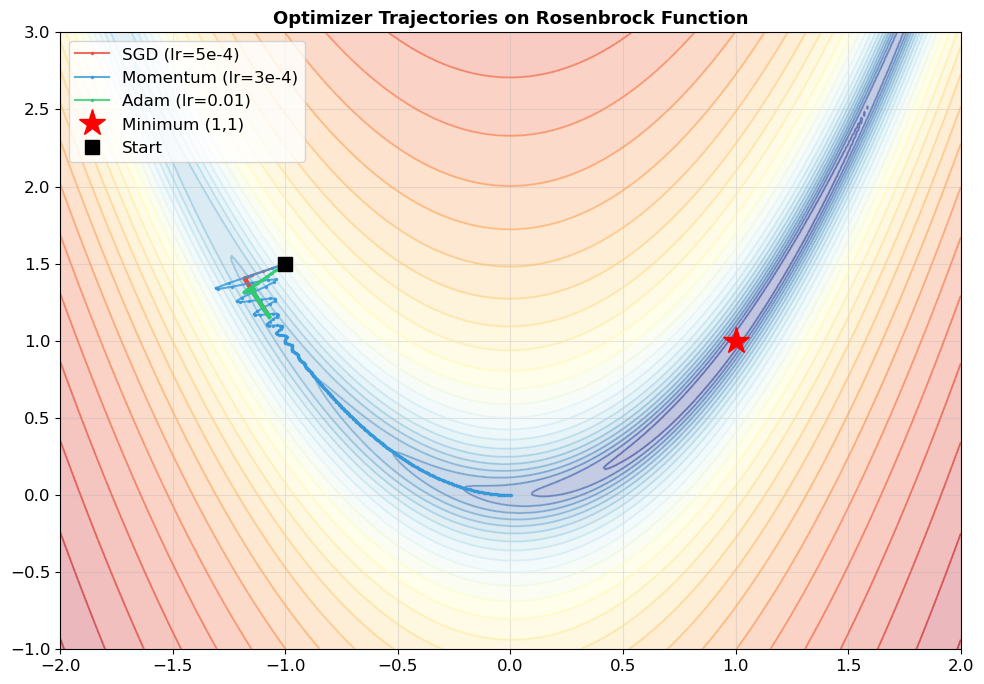

In [9]:

# Visualize optimizer trajectories on a 2D loss surface
sigmoid = lambda x: 1 / (1 + np.exp(-x))

def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def grad_rosenbrock(w):
    x, y = w
    gx = -2*(1-x) + 200*(y - x**2)*(-2*x)
    gy = 200*(y - x**2)
    return np.array([gx, gy])

def run_sgd(start, lr, steps):
    path = [start.copy()]
    w = start.copy()
    for _ in range(steps):
        w -= lr * grad_rosenbrock(w)
        path.append(w.copy())
    return np.array(path)

def run_momentum(start, lr, steps, beta=0.9):
    path = [start.copy()]
    w, v = start.copy(), np.zeros(2)
    for _ in range(steps):
        g = grad_rosenbrock(w)
        v = beta * v + g
        w -= lr * v
        path.append(w.copy())
    return np.array(path)

def run_adam(start, lr, steps, b1=0.9, b2=0.999, eps=1e-8):
    path = [start.copy()]
    w, m, v = start.copy(), np.zeros(2), np.zeros(2)
    for t in range(1, steps+1):
        g = grad_rosenbrock(w)
        m = b1*m + (1-b1)*g
        v = b2*v + (1-b2)*g**2
        w -= lr * (m/(1-b1**t)) / (np.sqrt(v/(1-b2**t)) + eps)
        path.append(w.copy())
    return np.array(path)

start = np.array([-1.0, 1.5])
n_steps = 300
paths = [
    ('SGD (lr=5e-4)',      run_sgd(start, 5e-4, n_steps),       '#e74c3c'),
    ('Momentum (lr=3e-4)', run_momentum(start, 3e-4, n_steps),  '#3498db'),
    ('Adam (lr=0.01)',     run_adam(start, 0.01, n_steps),       '#2ecc71'),
]

fig, ax = plt.subplots(figsize=(10, 7))
xx, yy = np.meshgrid(np.linspace(-2, 2, 300), np.linspace(-1, 3, 300))
zz = np.log1p(rosenbrock(xx, yy))
ax.contourf(xx, yy, zz, levels=30, cmap='RdYlBu_r', alpha=0.3)
ax.contour(xx, yy, zz, levels=30, cmap='RdYlBu_r', alpha=0.5)

for name, path, color in paths:
    ax.plot(path[:,0], path[:,1], '-o', color=color, markersize=1.5, linewidth=1.5, label=name, alpha=0.8)

ax.plot(1, 1, 'r*', markersize=20, zorder=10, label='Minimum (1,1)')
ax.plot(start[0], start[1], 'ks', markersize=10, zorder=10, label='Start')
ax.set_title('Optimizer Trajectories on Rosenbrock Function', fontweight='bold', fontsize=13)
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 5.4 Learning Rate Scheduling

| Schedule | Formula / Behavior | Used In |
|----------|-------------------|---------|
| **Step Decay** | $\eta = \eta_0 \cdot 0.1^{\lfloor \text{epoch}/30 \rfloor}$ | Classic CNNs |
| **Cosine Annealing** | $\eta = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min})(1 + \cos(\pi t/T))$ | Modern training |
| **Warm-up + Decay** | Ramp up, then decay | Transformers (essential!) |
| **ReduceOnPlateau** | Reduce when val loss stalls | General purpose |
| **One-Cycle** | Ramp up → ramp down aggressively | Super-convergence |

> 🎯 **Why warm-up?** Prevents large early gradients from destabilizing randomly-initialized weights.

---
# 6. Batch Normalization

## Algorithm

For each feature in a mini-batch of $m$ samples:

$$\mu_B = \frac{1}{m}\sum_{i=1}^{m} x_i, \qquad \sigma_B^2 = \frac{1}{m}\sum_{i=1}^{m}(x_i - \mu_B)^2$$

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \qquad y_i = \gamma \hat{x}_i + \beta$$

- $\gamma$ and $\beta$ are **learnable** — the network can undo normalization if needed
- **Placement:** typically `Linear → BN → ReLU`

## Training vs Inference

| | Training | Inference |
|---|---------|-----------|
| Stats | Current batch mean/var | **Running average** from training |
| Behavior | Stochastic (batch-dependent) | Deterministic |

> 🎯 **Interview question:** "What does BatchNorm do at test time?" — Uses exponential moving average of training statistics, NOT the test batch.

## Normalization Variants

| Type | Normalizes Over | Best For |
|------|----------------|----------|
| **BatchNorm** | Batch dimension | CNNs |
| **LayerNorm** | Feature dimension | Transformers |
| **InstanceNorm** | Per sample, per channel | Style transfer |
| **GroupNorm** | Groups of channels | Small batches |
| **RMSNorm** | RMS (no mean subtraction) | LLaMA, modern LLMs |

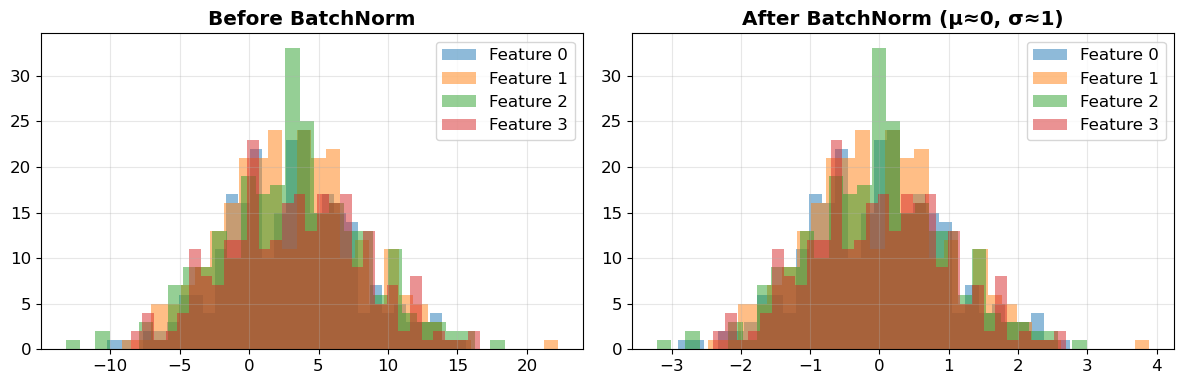

Before — Mean: [3.04 3.05 3.17 3.33], Std: [4.58 4.93 5.09 4.93]
After  — Mean: [-0.  0. -0.  0.], Std: [1. 1. 1. 1.]


In [10]:
# BatchNorm from scratch
class BatchNorm1D:
    def __init__(self, n_features, momentum=0.1, eps=1e-5):
        self.gamma = np.ones(n_features)
        self.beta = np.zeros(n_features)
        self.eps = eps
        self.momentum = momentum
        self.running_mean = np.zeros(n_features)
        self.running_var = np.ones(n_features)

    def forward(self, x, training=True):
        if training:
            mu = x.mean(axis=0)
            var = x.var(axis=0)
            x_norm = (x - mu) / np.sqrt(var + self.eps)
            self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*mu
            self.running_var = (1-self.momentum)*self.running_var + self.momentum*var
        else:
            x_norm = (x - self.running_mean) / np.sqrt(self.running_var + self.eps)
        return self.gamma * x_norm + self.beta

# Demo
np.random.seed(42)
batch = np.random.randn(256, 4) * 5 + 3  # badly scaled

bn = BatchNorm1D(4)
normalized = bn.forward(batch, training=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(4):
    axes[0].hist(batch[:, i], bins=30, alpha=0.5, label=f'Feature {i}')
axes[0].set_title('Before BatchNorm', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for i in range(4):
    axes[1].hist(normalized[:, i], bins=30, alpha=0.5, label=f'Feature {i}')
axes[1].set_title('After BatchNorm (μ≈0, σ≈1)', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Before — Mean: {batch.mean(axis=0).round(2)}, Std: {batch.std(axis=0).round(2)}")
print(f"After  — Mean: {normalized.mean(axis=0).round(4)}, Std: {normalized.std(axis=0).round(4)}")

---
# 7. Training Neural Networks — Complete Pipeline

## 7.1 The Training Loop (PyTorch pseudocode)

```python
model = MyModel()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

for epoch in range(num_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        pred = model(X_batch)           # Forward
        loss = criterion(pred, y_batch) # Loss
        loss.backward()                 # Backprop
        optimizer.step()                # Update
        optimizer.zero_grad()           # Zero grads!
    scheduler.step()

    model.eval()
    with torch.no_grad():              # No gradient tracking
        val_loss = evaluate(model, val_loader)
```

## 7.2 Key Definitions

| Term | Definition |
|------|-----------|
| **Epoch** | One complete pass through all training data |
| **Batch** | Subset of data processed together (e.g. 32 samples) |
| **Iteration** | One weight update = one batch. Per epoch: $N / B$ iterations |
| **Learning rate** | Step size for gradient descent |

## 7.3 Loss Functions

| Task | Loss | Notes |
|------|------|-------|
| Regression | MSE $\frac{1}{n}\sum(y-\hat{y})^2$ | Penalizes outliers heavily |
| Regression | MAE $\frac{1}{n}\sum|y-\hat{y}|$ | Robust to outliers |
| Regression | Huber | Best of MSE + MAE |
| Binary clf. | BCE $-[y\log p + (1-y)\log(1-p)]$ | |
| Multi-class | CE $-\sum y_i \log p_i$ | Use with softmax |
| Imbalanced | Focal $-(1-p)^\gamma \log p$ | Down-weights easy examples |
| Similarity | Contrastive / Triplet | Embedding learning |

> 🎯 **Why cross-entropy > MSE for classification?** CE gradients are proportional to the error magnitude. MSE saturates due to $\sigma'(z)$ — when predictions are very wrong, gradients are still tiny.

Train accuracy: 0.923
Val accuracy:   0.892


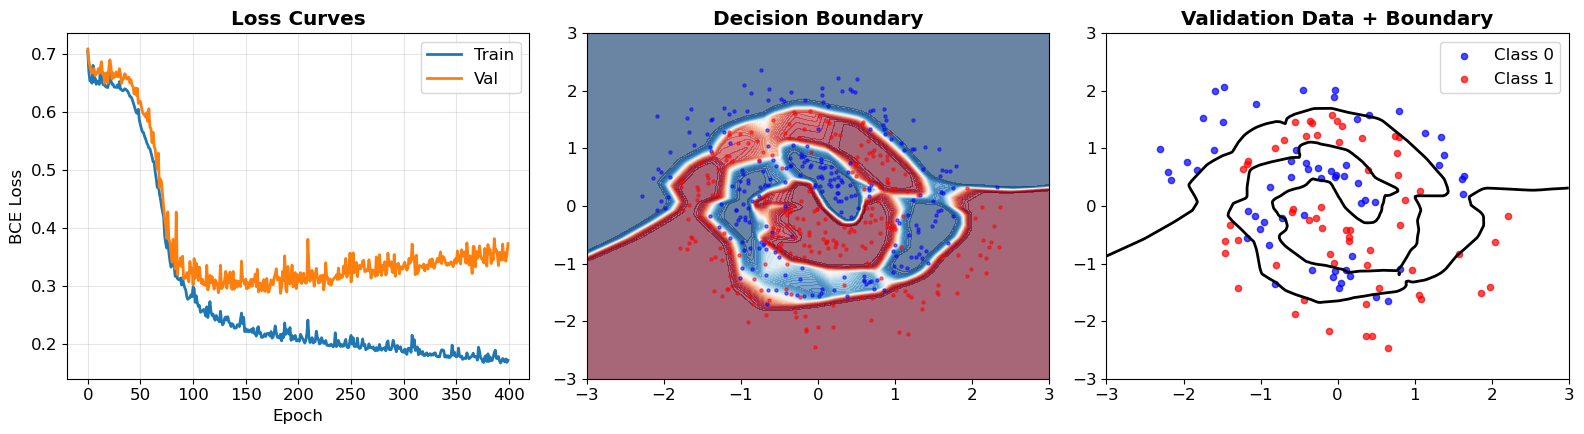

In [11]:
# Full training demo — spiral dataset classification from scratch
np.random.seed(42)

# Generate spiral data
def make_spirals(n=300, noise=0.3):
    t = np.linspace(0, 3*np.pi, n//2)
    r = np.linspace(0.5, 3, n//2)
    x1 = np.column_stack([r*np.cos(t)+noise*np.random.randn(n//2), r*np.sin(t)+noise*np.random.randn(n//2)])
    x2 = np.column_stack([r*np.cos(t+np.pi)+noise*np.random.randn(n//2), r*np.sin(t+np.pi)+noise*np.random.randn(n//2)])
    X = np.vstack([x1, x2])
    y = np.hstack([np.zeros(n//2), np.ones(n//2)])
    idx = np.random.permutation(len(y))
    return X[idx], y[idx]

X, y = make_spirals(600)
split = int(0.8 * len(y))
X_tr, X_val = X[:split], X[split:]
y_tr, y_val = y[:split], y[split:]
mu, sig = X_tr.mean(0), X_tr.std(0)
X_tr, X_val = (X_tr-mu)/sig, (X_val-mu)/sig

class NeuralNet:
    def __init__(self, dims=[2, 64, 32, 1], lr=0.005):
        self.W, self.b, self.lr = [], [], lr
        for i in range(len(dims)-1):
            self.W.append(np.random.randn(dims[i], dims[i+1]) * np.sqrt(2.0/dims[i]))
            self.b.append(np.zeros(dims[i+1]))
        self.m_w = [np.zeros_like(w) for w in self.W]
        self.v_w = [np.zeros_like(w) for w in self.W]
        self.m_b = [np.zeros_like(b) for b in self.b]
        self.v_b = [np.zeros_like(b) for b in self.b]
        self.t = 0

    def forward(self, X):
        self.activations = [X]
        self.pre_act = []
        h = X
        for i in range(len(self.W)):
            z = h @ self.W[i] + self.b[i]
            self.pre_act.append(z)
            h = np.maximum(0, z) if i < len(self.W)-1 else 1/(1+np.exp(-z))
            self.activations.append(h)
        return h

    def backward(self, y):
        m = y.shape[0]
        self.t += 1
        dz = self.activations[-1] - y.reshape(-1, 1)
        for i in range(len(self.W)-1, -1, -1):
            dW = self.activations[i].T @ dz / m
            db = dz.mean(axis=0)
            if i > 0:
                dz = (dz @ self.W[i].T) * (self.pre_act[i-1] > 0).astype(float)
            # Adam update
            for param, grad, mp, vp in [(self.W, dW, self.m_w, self.v_w),
                                         (self.b, db, self.m_b, self.v_b)]:
                mp[i] = 0.9*mp[i] + 0.1*grad
                vp[i] = 0.999*vp[i] + 0.001*grad**2
                mh = mp[i]/(1-0.9**self.t)
                vh = vp[i]/(1-0.999**self.t)
                param[i] -= self.lr * mh / (np.sqrt(vh)+1e-8)

    def loss(self, X, y):
        p = np.clip(self.forward(X).flatten(), 1e-7, 1-1e-7)
        return -np.mean(y*np.log(p) + (1-y)*np.log(1-p))

    def accuracy(self, X, y):
        return np.mean((self.forward(X).flatten() > 0.5) == y)

model = NeuralNet()
train_losses, val_losses = [], []

for epoch in range(400):
    idx = np.random.permutation(len(y_tr))
    for s in range(0, len(y_tr), 32):
        bi = idx[s:s+32]
        model.forward(X_tr[bi])
        model.backward(y_tr[bi])
    train_losses.append(model.loss(X_tr, y_tr))
    val_losses.append(model.loss(X_val, y_val))

print(f"Train accuracy: {model.accuracy(X_tr, y_tr):.3f}")
print(f"Val accuracy:   {model.accuracy(X_val, y_val):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(train_losses, label='Train', lw=2); axes[0].plot(val_losses, label='Val', lw=2)
axes[0].set_title('Loss Curves', fontweight='bold'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')

xx, yy = np.meshgrid(np.linspace(-3,3,200), np.linspace(-3,3,200))
zz = model.forward(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
axes[1].contourf(xx, yy, zz, levels=50, cmap='RdBu_r', alpha=0.6)
axes[1].scatter(X_tr[y_tr==0,0], X_tr[y_tr==0,1], c='blue', s=5, alpha=0.5)
axes[1].scatter(X_tr[y_tr==1,0], X_tr[y_tr==1,1], c='red', s=5, alpha=0.5)
axes[1].set_title('Decision Boundary', fontweight='bold')

axes[2].scatter(X_val[y_val==0,0], X_val[y_val==0,1], c='blue', s=20, alpha=0.7, label='Class 0')
axes[2].scatter(X_val[y_val==1,0], X_val[y_val==1,1], c='red', s=20, alpha=0.7, label='Class 1')
axes[2].contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=2)
axes[2].set_title('Validation Data + Boundary', fontweight='bold'); axes[2].legend()

plt.tight_layout(); plt.show()

---
# 8. Overfitting & Regularization

## 8.1 Overfitting vs Underfitting

| | Underfitting | Good Fit | Overfitting |
|---|-------------|----------|-------------|
| **Train loss** | High | Low | Very low |
| **Val loss** | High | Low | High |
| **Bias** | High | Low | Low |
| **Variance** | Low | Low | High |

$$\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

## 8.2 ALL Regularization Techniques

### Explicit Regularization
- **L2 (Weight Decay):** $\mathcal{L} += \lambda \sum w^2$ — shrinks weights toward 0
- **L1 (Lasso):** $\mathcal{L} += \lambda \sum |w|$ — induces sparsity
- **Elastic Net:** L1 + L2 combined

### Dropout
- Randomly zero out neurons with probability $p$ during training
- At test time: multiply weights by $(1-p)$ **or** use inverted dropout (divide by $1-p$ during training)
- Interpretation: implicit ensemble of $2^n$ subnetworks

### Data-Level
- **Data augmentation** (flips, rotations, crops, Mixup, CutMix, CutOut)
- **More training data** (always the best regularizer)

### Architectural
- Batch/Layer Normalization
- Residual connections
- Reduce model capacity

### Training-Level
- **Early stopping** — stop when val loss starts increasing
- **Label smoothing** — use $y = 0.9$ instead of $1.0$
- **Stochastic depth** — randomly drop entire layers during training

> 🎯 **Interview tip:** Dropout ($p=0.2$-$0.5$) and weight decay are the two most common. Know them cold.

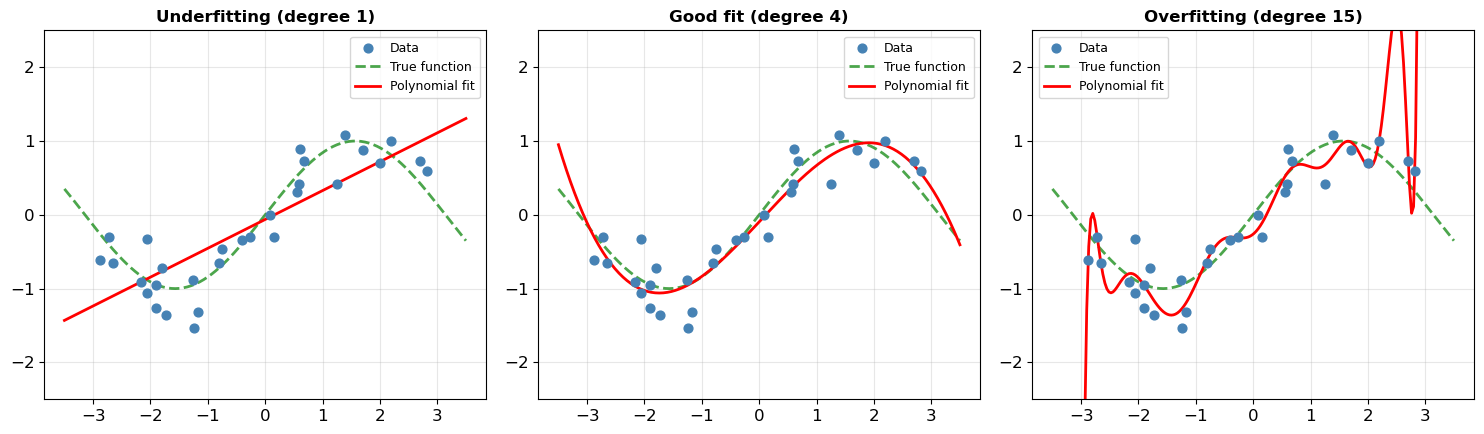

In [12]:
# Demonstrate overfitting vs regularization
np.random.seed(42)

# Simple polynomial data
n = 30
x = np.sort(np.random.uniform(-3, 3, n))
y_true = np.sin(x)
y = y_true + 0.3 * np.random.randn(n)

# Fit polynomials of different degrees
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
x_plot = np.linspace(-3.5, 3.5, 200)

for ax, degree, label in [(axes[0], 1, 'Underfitting (degree 1)'),
                           (axes[1], 4, 'Good fit (degree 4)'),
                           (axes[2], 15, 'Overfitting (degree 15)')]:
    coeffs = np.polyfit(x, y, degree)
    y_pred = np.polyval(coeffs, x_plot)
    ax.scatter(x, y, c='steelblue', s=40, zorder=5, label='Data')
    ax.plot(x_plot, np.sin(x_plot), 'g--', linewidth=2, label='True function', alpha=0.7)
    ax.plot(x_plot, y_pred, 'r-', linewidth=2, label=f'Polynomial fit')
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_ylim(-2.5, 2.5); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [13]:
# Dropout implementation from scratch
class DropoutLayer:
    def __init__(self, p=0.5):
        self.p = p  # probability of DROPPING a neuron
        self.mask = None

    def forward(self, x, training=True):
        if training:
            # Inverted dropout: scale during training so no change needed at test time
            self.mask = (np.random.rand(*x.shape) > self.p).astype(float) / (1 - self.p)
            return x * self.mask
        else:
            return x  # No dropout at test time (already scaled)

# Demo
np.random.seed(42)
x = np.random.randn(1, 10)
dropout = DropoutLayer(p=0.5)

print("Input:         ", np.round(x, 2))
print("After dropout: ", np.round(dropout.forward(x, training=True), 2))
print("Mask (scaled): ", np.round(dropout.mask, 2))
print("Test time:     ", np.round(dropout.forward(x, training=False), 2))
print("\nNotice: surviving neurons are scaled by 1/(1-p) = 2.0 to maintain expected value.")

Input:          [[ 0.5  -0.14  0.65  1.52 -0.23 -0.23  1.58  0.77 -0.47  0.54]]
After dropout:  [[ 0.   -0.    0.    3.05 -0.   -0.    3.16  0.   -0.    0.  ]]
Mask (scaled):  [[0. 0. 0. 2. 0. 0. 2. 0. 0. 0.]]
Test time:      [[ 0.5  -0.14  0.65  1.52 -0.23 -0.23  1.58  0.77 -0.47  0.54]]

Notice: surviving neurons are scaled by 1/(1-p) = 2.0 to maintain expected value.


---
# 9. Transfer Learning

## Core Idea

Reuse a model trained on a large dataset (e.g., ImageNet) for a different, usually smaller, task.

**Why it works:** Early layers learn universal features (edges, textures, shapes). Later layers learn task-specific features.

## Strategies

| Strategy | What to do | When to use |
|----------|-----------|-------------|
| **Feature Extraction** | Freeze all pretrained layers, train only the new head | Small dataset, similar domain |
| **Fine-tuning (partial)** | Unfreeze top layers, freeze early layers | Medium dataset, somewhat different domain |
| **Full Fine-tuning** | Unfreeze everything, use small LR | Large dataset |

### Discriminative Learning Rates

Use different learning rates per layer — smaller for early (pretrained) layers, larger for later layers:

```python
optimizer = torch.optim.Adam([
    {'params': model.layer1.parameters(), 'lr': 1e-5},
    {'params': model.layer2.parameters(), 'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3},
])
```

## Modern Parameter-Efficient Fine-Tuning (PEFT)

| Method | Idea | Params Trained |
|--------|------|---------------|
| **LoRA** | $W' = W + BA$ where $B \in \mathbb{R}^{d \times r}$, $A \in \mathbb{R}^{r \times d}$, $r \ll d$ | ~0.1% of full model |
| **Adapters** | Small trainable bottleneck modules between frozen layers | ~2-5% |
| **Prefix Tuning** | Learnable "virtual tokens" prepended to input | ~0.1% |
| **Prompt Tuning** | Learn continuous prompt embeddings | ~0.01% |

## Transfer Learning by Domain

| Domain | Pretrained On | Examples |
|--------|--------------|---------|
| **Vision** | ImageNet | ResNet, EfficientNet, ViT |
| **NLP** | Large text corpora | BERT, GPT, T5, LLaMA |
| **Audio** | Speech/audio data | Whisper, wav2vec |
| **Multi-modal** | Image-text pairs | CLIP, DALL-E |

> 🎯 **Interview tip:** LoRA is now the standard for fine-tuning large models. Know the math: only $A$ and $B$ are trained, with rank $r$ typically 4-64.

In [14]:
# Simulating transfer learning: feature extraction vs fine-tuning
np.random.seed(42)

print("=" * 60)
print("TRANSFER LEARNING SIMULATION")
print("=" * 60)

# Pretrained "feature extractor" (simulated)
# Imagine these are features from a ResNet pretrained on ImageNet
n_samples = 200
# Source domain: learned good features
pretrained_features = np.random.randn(n_samples, 10)
# Target labels (new task)
y = (pretrained_features[:, 0] + pretrained_features[:, 3] > 0).astype(float)

# Split
X_tr, X_te = pretrained_features[:150], pretrained_features[150:]
y_tr, y_te = y[:150], y[150:]

# Strategy 1: Feature Extraction (train only classifier head)
from collections import defaultdict

print("\n1. FEATURE EXTRACTION (freeze backbone, train head only):")
print("   - Fastest training")
print("   - Works well when domains are similar")
W = np.random.randn(10, 1) * 0.1
b = 0.0
lr = 0.1

for epoch in range(100):
    # Simple logistic regression as "head"
    z = X_tr @ W + b
    a = 1 / (1 + np.exp(-z))
    dz = a - y_tr.reshape(-1, 1)
    W -= lr * (X_tr.T @ dz / len(y_tr))
    b -= lr * dz.mean()

pred = (1/(1+np.exp(-(X_te @ W + b))) > 0.5).flatten().astype(float)
acc = np.mean(pred == y_te)
print(f"   Test accuracy: {acc:.3f}")
print(f"   Parameters trained: 11 (10 weights + 1 bias)")

# Strategy 2: Full Fine-tuning (more params)
print("\n2. FULL FINE-TUNING (update everything):")
print("   - Slower, needs more data")
print("   - Better when domains differ significantly")
print("   - Use smaller LR for pretrained layers!")
print(f"   Would train: ALL backbone + head parameters")

# LoRA simulation
print("\n3. LoRA (Low-Rank Adaptation):")
d, r = 10, 2  # d = hidden dim, r = rank
A = np.random.randn(r, d) * 0.01
B = np.zeros((d, r))  # initialized to zero so ΔW starts at 0
print(f"   Original weight matrix: {d}×{d} = {d*d} params")
print(f"   LoRA matrices B({d}×{r}) + A({r}×{d}) = {d*r + r*d} params")
print(f"   Reduction: {d*d}/{d*r+r*d} = {d*d/(d*r+r*d):.1f}× fewer params!")
print(f"   W' = W + B @ A  (W frozen, only B and A trained)")

TRANSFER LEARNING SIMULATION

1. FEATURE EXTRACTION (freeze backbone, train head only):
   - Fastest training
   - Works well when domains are similar
   Test accuracy: 0.860
   Parameters trained: 11 (10 weights + 1 bias)

2. FULL FINE-TUNING (update everything):
   - Slower, needs more data
   - Better when domains differ significantly
   - Use smaller LR for pretrained layers!
   Would train: ALL backbone + head parameters

3. LoRA (Low-Rank Adaptation):
   Original weight matrix: 10×10 = 100 params
   LoRA matrices B(10×2) + A(2×10) = 40 params
   Reduction: 100/40 = 2.5× fewer params!
   W' = W + B @ A  (W frozen, only B and A trained)


---
# 10. Convolutional Neural Networks (CNNs)

## Key Insight

Exploit **spatial structure** with:
1. **Local connectivity** — each neuron sees only a small region
2. **Weight sharing** — same filter applied everywhere
3. **Translation equivariance** — same feature detected regardless of position

## Convolution Operation

$$\text{Output}[i,j] = \sum_m \sum_n \text{Input}[i+m, j+n] \cdot \text{Kernel}[m,n] + \text{bias}$$

### Output Size Formula

$$O = \frac{I - K + 2P}{S} + 1$$

| Symbol | Meaning | Typical Values |
|--------|---------|---------------|
| $I$ | Input size | 224, 32, etc. |
| $K$ | Kernel size | 3, 5, 7 |
| $P$ | Padding | 0, 1 (same padding: $P = (K-1)/2$) |
| $S$ | Stride | 1, 2 |

## CNN Building Blocks

| Layer | Purpose |
|-------|---------|
| **Conv2d** | Learn spatial filters |
| **Pooling** (Max/Avg) | Downsample, add invariance |
| **BatchNorm** | Stabilize training |
| **Dropout** | Regularize FC layers |
| **1×1 Conv** | Change channel depth without affecting spatial dims |
| **Global Avg Pool** | Replace FC layers (fewer params) |

## Landmark Architectures

| Model | Year | Key Innovation | Depth |
|-------|------|---------------|-------|
| **LeNet-5** | 1998 | Pioneer CNN | 5 |
| **AlexNet** | 2012 | ReLU, Dropout, GPU training | 8 |
| **VGGNet** | 2014 | All 3×3 convs, deeper = better | 16/19 |
| **GoogLeNet** | 2014 | Inception modules (parallel convs) | 22 |
| **ResNet** | 2015 | **Skip connections** $y = F(x) + x$ | 50/101/152 |
| **DenseNet** | 2017 | Connect each layer to ALL others | 121+ |
| **EfficientNet** | 2019 | Compound scaling (depth×width×resolution) | varies |
| **ViT** | 2020 | Patch embeddings → Transformer | 12/24 |

> 🎯 **Must-know:** ResNet skip connections. Be able to explain:
> 1. How $y = F(x) + x$ helps gradient flow ($\frac{\partial y}{\partial x} = \frac{\partial F}{\partial x} + 1$)
> 2. Why learning a residual $F(x) = H(x) - x$ is easier than $H(x)$ directly

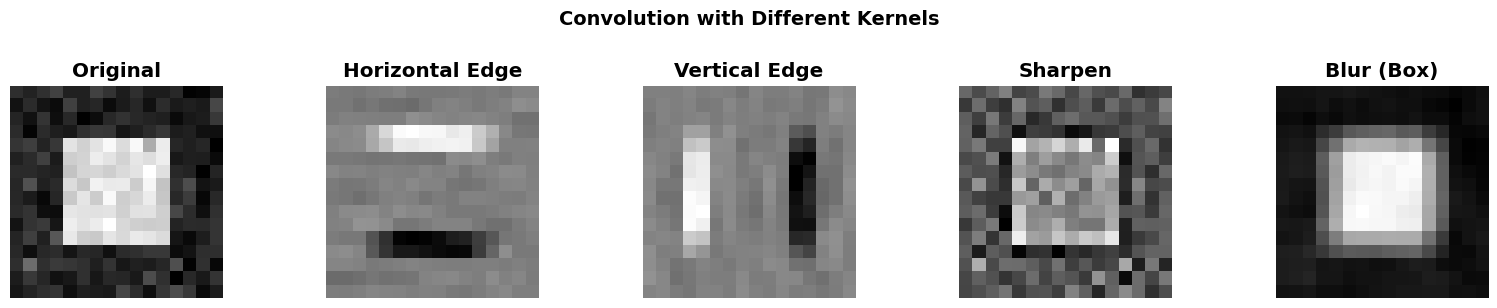


Output Size Calculator:
  Input=224, Kernel=7, Padding=0, Stride=2 → Output=109
  Input=32, Kernel=3, Padding=1, Stride=1 → Output=32
  Input=28, Kernel=5, Padding=0, Stride=1 → Output=24
  Input=56, Kernel=3, Padding=1, Stride=2 → Output=28


In [15]:
# 2D Convolution from scratch
def conv2d(image, kernel, stride=1, padding=0):
    """2D convolution operation."""
    if padding > 0:
        image = np.pad(image, padding, mode='constant')
    h, w = image.shape
    kh, kw = kernel.shape
    out_h = (h - kh) // stride + 1
    out_w = (w - kw) // stride + 1
    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            region = image[i*stride:i*stride+kh, j*stride:j*stride+kw]
            output[i, j] = np.sum(region * kernel)
    return output

# Create a simple image
np.random.seed(42)
image = np.zeros((16, 16))
image[4:12, 4:12] = 1  # white square
image += 0.1 * np.random.randn(16, 16)

# Common filters
filters = {
    'Horizontal Edge': np.array([[-1,-1,-1],[0,0,0],[1,1,1]]),
    'Vertical Edge': np.array([[-1,0,1],[-1,0,1],[-1,0,1]]),
    'Sharpen': np.array([[0,-1,0],[-1,5,-1],[0,-1,0]]),
    'Blur (Box)': np.ones((3,3)) / 9,
}

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
axes[0].imshow(image, cmap='gray'); axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

for ax, (name, kernel) in zip(axes[1:], filters.items()):
    result = conv2d(image, kernel, padding=1)
    ax.imshow(result, cmap='gray'); ax.set_title(name, fontweight='bold')
    ax.axis('off')

plt.suptitle('Convolution with Different Kernels', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Output size calculator
print("\nOutput Size Calculator:")
configs = [(224, 7, 0, 2), (32, 3, 1, 1), (28, 5, 0, 1), (56, 3, 1, 2)]
for I, K, P, S in configs:
    O = (I - K + 2*P) // S + 1
    print(f"  Input={I}, Kernel={K}, Padding={P}, Stride={S} → Output={O}")

---
# 11. RNNs, LSTMs & Sequence Models

## 11.1 Vanilla RNN

$$h_t = \tanh(W_{hh} \cdot h_{t-1} + W_{xh} \cdot x_t + b_h)$$
$$y_t = W_{hy} \cdot h_t + b_y$$

- Same weights $W$ shared across ALL timesteps
- **BPTT (Backpropagation Through Time):** Unroll and apply standard backprop

### Why RNNs fail on long sequences:

$$\frac{\partial h_t}{\partial h_k} = \prod_{i=k}^{t-1} W_{hh} \cdot \text{diag}(\sigma'(z_i))$$

- Eigenvalue of $W_{hh} < 1$ → **vanishing** (can't remember 50+ steps ago)
- Eigenvalue of $W_{hh} > 1$ → **exploding**

## 11.2 LSTM (Long Short-Term Memory)

Key innovation: **Cell state** $C_t$ — an information highway with **additive** (not multiplicative) interactions.

### The Four Components:

**1. Forget Gate** — what to erase:
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

**2. Input Gate** — what to write:
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$$

**3. Cell State Update:**
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

**4. Output Gate** — what to output:
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$

### Why LSTM solves vanishing gradient:
$$\frac{\partial C_t}{\partial C_{t-1}} = f_t$$
When $f_t \approx 1$, gradients flow **unchanged** through the cell state!

## 11.3 GRU (Gated Recurrent Unit)

Simplified LSTM — merges cell/hidden state, 2 gates instead of 3:

$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t]) \qquad \text{(update gate)}$$
$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t]) \qquad \text{(reset gate)}$$
$$\tilde{h}_t = \tanh(W \cdot [r_t \odot h_{t-1}, x_t])$$
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

## 11.4 Beyond RNNs

| Model | Key Idea | Advantage |
|-------|----------|-----------|
| **Bidirectional RNN** | Process forwards AND backwards | Full context |
| **Seq2Seq** | Encoder → context → Decoder | Variable-length I/O |
| **Attention** | Attend to all encoder states | No bottleneck |
| **Transformer** | Self-attention replaces recurrence | **Parallelizable!** |

> 🎯 **Why Transformers won:** Fully parallelizable (no sequential dependency), better long-range dependencies, more scalable.

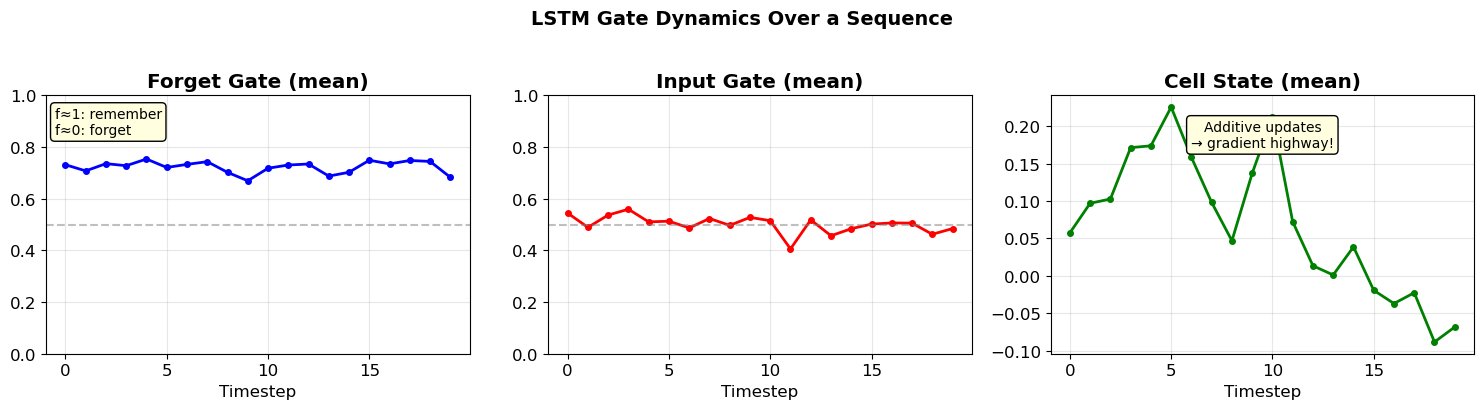

In [16]:
# LSTM from scratch — character-level sequence prediction
class LSTM_Cell:
    """Single LSTM cell."""
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size
        scale = np.sqrt(2.0 / (input_size + hidden_size))
        # Combined weight matrix for all 4 gates: [f, i, c_tilde, o]
        self.Wh = np.random.randn(hidden_size, 4 * hidden_size) * scale
        self.Wx = np.random.randn(input_size, 4 * hidden_size) * scale
        self.b = np.zeros(4 * hidden_size)
        # Initialize forget gate bias to 1 (helps with long-range dependencies)
        self.b[:hidden_size] = 1.0

    def forward(self, x, h_prev, c_prev):
        H = self.hidden_size
        # All gates in one matmul (efficient!)
        gates = x @ self.Wx + h_prev @ self.Wh + self.b

        f = sigmoid(gates[:, :H])           # forget gate
        i = sigmoid(gates[:, H:2*H])        # input gate
        c_tilde = np.tanh(gates[:, 2*H:3*H]) # candidate
        o = sigmoid(gates[:, 3*H:])          # output gate

        c = f * c_prev + i * c_tilde         # cell state update
        h = o * np.tanh(c)                   # hidden state

        return h, c, (f, i, c_tilde, o)

sigmoid = lambda x: 1 / (1 + np.exp(-np.clip(x, -500, 500)))

# Demonstrate LSTM gate dynamics
np.random.seed(42)
H = 8
lstm = LSTM_Cell(input_size=4, hidden_size=H)

# Process a sequence
seq_len = 20
x_seq = np.random.randn(seq_len, 1, 4) * 0.5
h, c = np.zeros((1, H)), np.zeros((1, H))

forget_gates = []
input_gates = []
cell_states = []

for t in range(seq_len):
    h, c, (f, i, ct, o) = lstm.forward(x_seq[t], h, c)
    forget_gates.append(f.mean())
    input_gates.append(i.mean())
    cell_states.append(c.mean())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(forget_gates, 'b-o', markersize=4, linewidth=2)
axes[0].set_title('Forget Gate (mean)', fontweight='bold')
axes[0].set_xlabel('Timestep'); axes[0].set_ylim(0, 1); axes[0].grid(True, alpha=0.3)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].annotate('f≈1: remember\nf≈0: forget', xy=(0.02, 0.85), xycoords='axes fraction',
                fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow'))

axes[1].plot(input_gates, 'r-o', markersize=4, linewidth=2)
axes[1].set_title('Input Gate (mean)', fontweight='bold')
axes[1].set_xlabel('Timestep'); axes[1].set_ylim(0, 1); axes[1].grid(True, alpha=0.3)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)

axes[2].plot(cell_states, 'g-o', markersize=4, linewidth=2)
axes[2].set_title('Cell State (mean)', fontweight='bold')
axes[2].set_xlabel('Timestep'); axes[2].grid(True, alpha=0.3)
axes[2].annotate('Additive updates\n→ gradient highway!', xy=(0.5, 0.8), xycoords='axes fraction',
                fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.suptitle('LSTM Gate Dynamics Over a Sequence', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---
# 12. Interview Rapid-Fire Q&A

## Frequently Asked Questions

**Q: Epoch vs Batch vs Iteration?**
- **Epoch** = 1 full pass through all data
- **Batch** = subset processed together
- **Iteration** = 1 update. With $N$ samples and batch $B$: iterations/epoch = $N/B$

**Q: What if learning rate is too high/too low?**
- Too high → loss oscillates or diverges
- Too low → slow convergence, can get stuck

**Q: BatchNorm at test time?**
- Uses **running mean/variance** from training (exponential moving average), NOT test batch statistics

**Q: Why softmax + cross-entropy?**
- Combined gradient: $\partial L/\partial z = \text{softmax}(z) - y$ — no $\sigma'$ term, no vanishing gradient at output

**Q: Can you use ReLU in the output layer?**
- Generally no. Use sigmoid (binary), softmax (multi-class), or linear (regression)

**Q: Why shuffle training data?**
- Prevents learning order-dependent patterns; ensures representative batches

**Q: Parameters vs hyperparameters?**
- **Parameters:** learned (weights, biases)
- **Hyperparameters:** set by you (LR, batch size, architecture)

**Q: When to use CNN vs RNN vs Transformer?**
- **CNN:** Spatial data (images), fixed-size local patterns
- **RNN/LSTM:** Sequential data when order matters AND you lack compute
- **Transformer:** Default choice for NLP; increasingly for vision, audio, everything

**Q: What is the difference between model.train() and model.eval() in PyTorch?**
- `train()`: Dropout active, BatchNorm uses batch statistics
- `eval()`: Dropout disabled, BatchNorm uses running statistics

**Q: How does gradient clipping work?**
- If $\|g\| > \text{threshold}$: $g = \text{threshold} \cdot \frac{g}{\|g\|}$
- Caps gradient magnitude, prevents exploding gradients (especially in RNNs)

**Q: What makes ResNet so important?**
- Skip connections: $y = F(x) + x$
- Gradient: $\frac{\partial y}{\partial x} = \frac{\partial F}{\partial x} + \mathbf{1}$ — the $+1$ prevents vanishing!
- Enabled training networks with 100+ layers

---

## 🎯 Interview Preparation Checklist

- [ ] Can explain perceptron → MLP → why non-linearity matters
- [ ] Can derive backpropagation step-by-step using chain rule
- [ ] Can compare activation functions and explain tradeoffs
- [ ] Can explain vanishing/exploding gradients + solutions
- [ ] Can write Adam update equations from memory
- [ ] Can explain BatchNorm (training vs inference)
- [ ] Know the full training pipeline + loss functions
- [ ] Can explain dropout, L2, early stopping, and when to use each
- [ ] Understand transfer learning strategies (feature extraction vs fine-tuning vs LoRA)
- [ ] Can explain CNN architecture + output size formula
- [ ] Can draw LSTM cell and explain all 4 components
- [ ] Know when to use CNN vs RNN vs Transformer

---

*Built for ML interview prep. Run every cell, understand every equation, ace the interview.* 🚀